# Soft Robot Control Framework Tutorial

This notebook demonstrates how to use the PCC soft robot framework for:

1. Building the PCC model.
2. Configuring a Model Predictive Controller (MPC).
3. Running closed-loop simulations.
4. Configuring a Nash Equilibrium Seeking controller.
5. Comparing both approaches.

The notebook is intended as both documentation and a practical tutorial.


# 1. Imports

In [1]:
import numpy as np
import casadi as cas
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = True

from pcc_modeling import *
from pcc_mpc import *
from pcc_NE_seeking import *
from Metrics import *


# 2. Framework Architecture

```text
                 PCC_model
                      |
     ----------------------------------
     |                                |
PCC_MPC_Controller         NE_Seeking_Controller
     |                                |
PCC_MPC_Simulator       NE_Seeking_Simulation
```

The PCC model contains the robot dynamics. Controllers generate the torque inputs, while simulators execute closed-loop experiments.


# 3. Building the PCC Robot Model

The PCC robot is represented by curvature coordinates:

$q = [q_1, q_2, q_3]^T$

The model automatically generates:

- Inertia matrix
- Coriolis/Centrifugal terms
- Gravity vector
- Continuous dynamics
- Discrete dynamics


In [2]:
# ============================================================
# CREATE PCC MODEL
# ============================================================

model = PCC_model()

model.create_model()

# ============================================================
# DISCRETIZATION
# ============================================================

dt = 1e-2

model.create_discretization(dt)

print("Number of states:", model.nx)
print("Number of inputs:", model.nu)


Number of states: 6
Number of inputs: 3


# 4. MPC Controller

The MPC solves a finite-horizon optimal control problem:

$J = \sum e_k^TQe_k + u_k^TRu_k + \Delta u_k^TS\Delta u_k$

subject to the PCC dynamics.


In [3]:
# ============================================================
# CREATE MPC CONTROLLER
# ============================================================

mpc = PCC_MPC_Controller(model)

N = 5

mpc.set_params(
    N=N,
    dt=dt
)

Q = np.diag([100,100,100,1,1,1])
R = 0.01*np.eye(model.nu)
S = 0.1*np.eye(model.nu)
P = Q

mpc.set_obj_function_params(
    Q=Q,
    R=R,
    S=S,
    P=P
)

mpc.setup_controller()

print("MPC controller successfully built.")


MPC controller successfully built.


# 5. Reference Trajectory

The controller requires a function returning the future reference trajectory over the prediction horizon.


In [4]:
def reference_function(t0, N, dt):

    X_ref = np.zeros((model.nx, N+1))

    for k in range(N+1):

        q_ref = np.array([0.20,0.25,0.30])

        qd_ref = np.zeros(model.n)

        X_ref[:,k] = np.concatenate([
            q_ref,
            qd_ref
        ])

    return X_ref


# 6. Closed-Loop MPC Simulation

At each sampling instant:

1. Generate reference trajectory.
2. Solve MPC optimization.
3. Apply first optimal input.
4. Propagate robot dynamics.
5. Store results.


Running simulation...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |        0 (       0)  36.00us ( 12.00us)         3
       nlp_g  |        0 (       0) 401.00us (133.67us)         3
  nlp_grad_f  |        0 (       0) 401.00us (100.25us)         4
  nlp_hess_l  |  20.00ms ( 10.00ms)  17.30ms (  8.65ms)         2
   nlp_jac_g  |  21.00ms (  5.25ms)   9.05ms (  2.26ms)         4
       total  |  52.00ms ( 52.00ms)  50.72ms ( 50.72ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |        0 (       0)  33.00us ( 11.00us)        

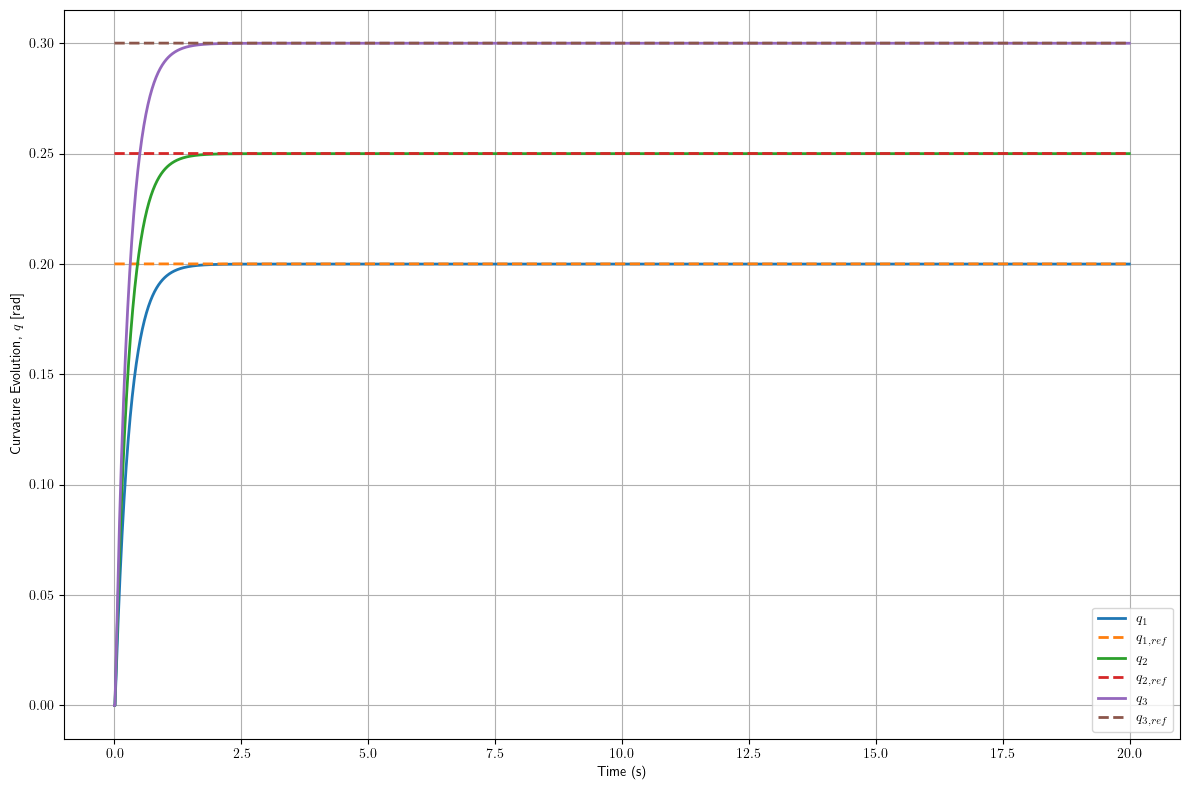

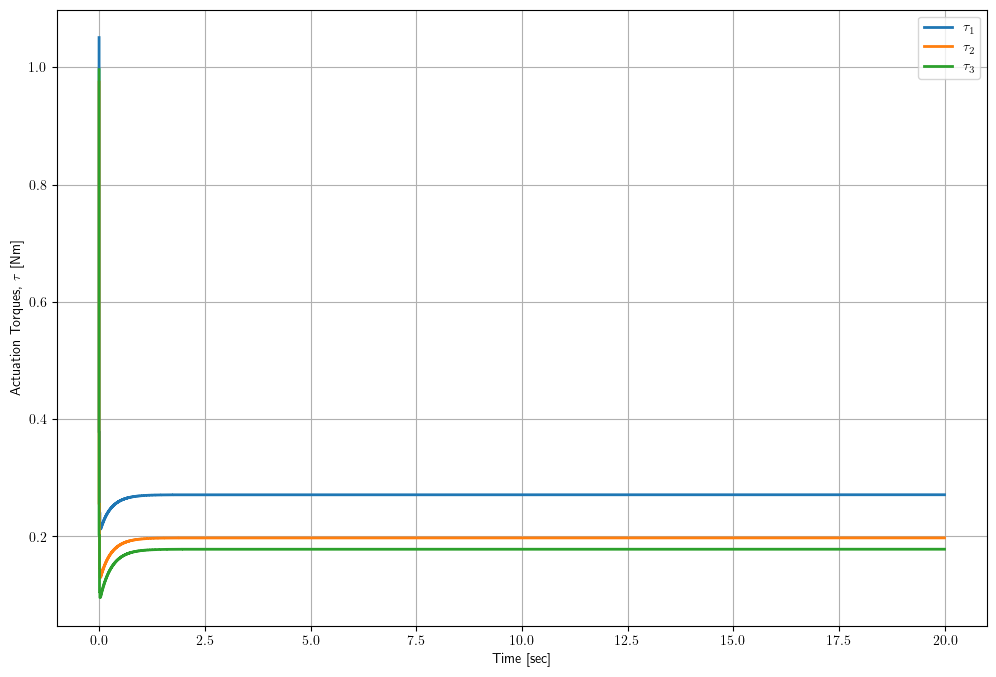

In [5]:
# ============================================================
# CREATE SIMULATOR
# ============================================================

sim = PCC_MPC_Simulator(model)

x0 = np.zeros(model.nx)

T = 20

n_steps = int(T/dt)

sim.run_closed_loop(
    controller=mpc,
    x_0=x0,
    n_steps=n_steps,
    reference_function=reference_function
)

sim.plot_results(
    filename=["pcc_mpc_q","pcc_mpc_tau"],
    save=True
)


# 7. Nash Equilibrium Seeking Controller

In this formulation each PCC section behaves as a player in a differential game.

The control law is

$u_i = k_{p,i}(z_i-q_i)-k_{d,i}\dot q_i$

where the virtual equilibria $z_i$ are adapted online using extremum-seeking dynamics.


In [6]:
# ============================================================
# CREATE ROBOT
# ============================================================

N = 3

robot = PCC_model(n=N)

robot.create_model()

q_star = np.array([0.2,0.25,0.3])

NE_controller = NE_Seeking_Controller(
    pcc_model = robot,
    n_players=N,
    q_star=q_star,
    kp=1000*np.ones(N),
    kd=20*np.ones(N),
    alpha=150*np.ones(N),
    beta=5*np.ones(N),
    k_es=np.array([2.76, 2.66, 1.627]),
    omega=np.array([110,140,115]),
    omega_l=0.5*np.ones(N),
    omega_h=0.5*np.ones(N),
    b=0.0001*np.ones(N),
    z_max=1,
    u_max=10.0
)

print("NE controller created.")


NE controller created.


# 8. Run NE-Seeking Simulation

The simulator:

1. Computes the payoff.
2. Updates equilibrium estimates.
3. Applies torque commands.
4. Integrates PCC dynamics using RK4.
5. Computes KPIs.


Running simulation...
Simulation completed in 7.99 s

================ KPIs ================

Section 1
IAE  = 0.047564
ISE  = 0.002104
ITAE = 0.378338
RMSE = 0.010306
-----------------------------------
Section 2
IAE  = 0.031866
ISE  = 0.003624
ITAE = 0.166659
RMSE = 0.013519
-----------------------------------
Section 3
IAE  = 0.032128
ISE  = 0.006007
ITAE = 0.101672
RMSE = 0.017396
-----------------------------------
Metrics - Average along sections: 
IAE  = 0.037186
ISE  = 0.003912
ITAE = 0.215556
RMSE = 0.013740


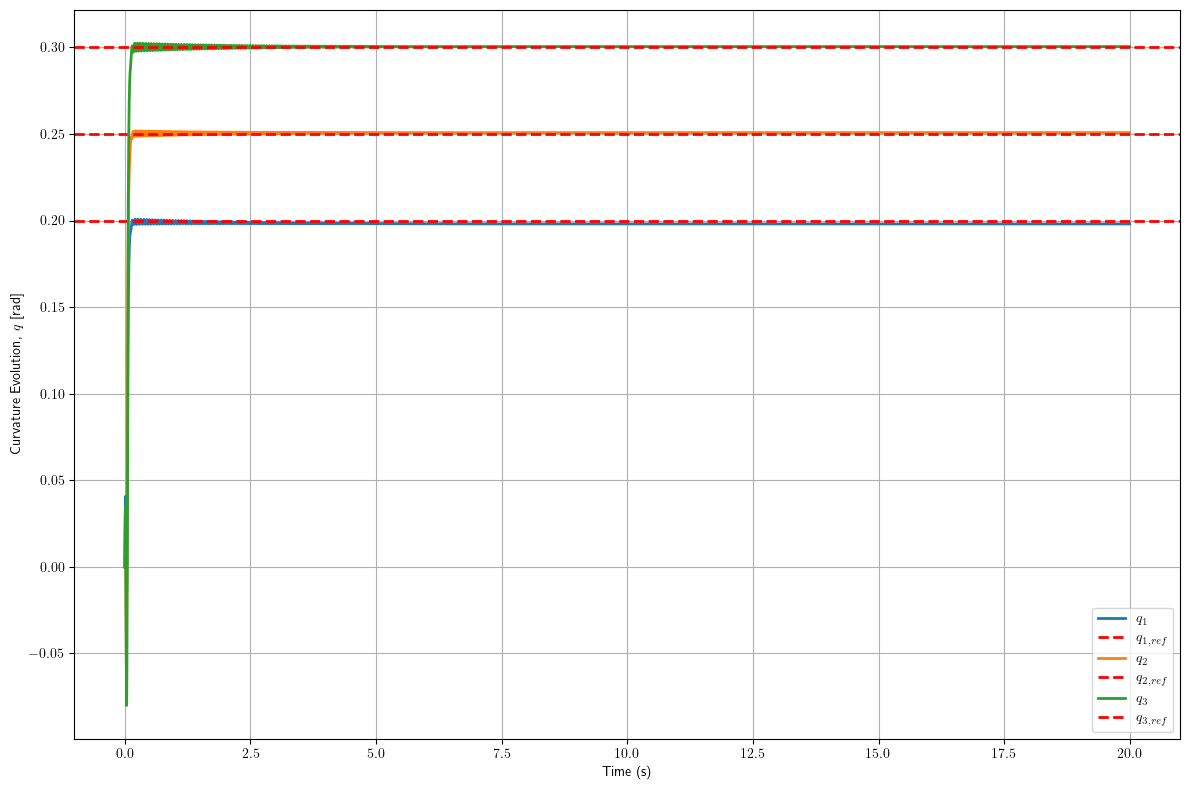

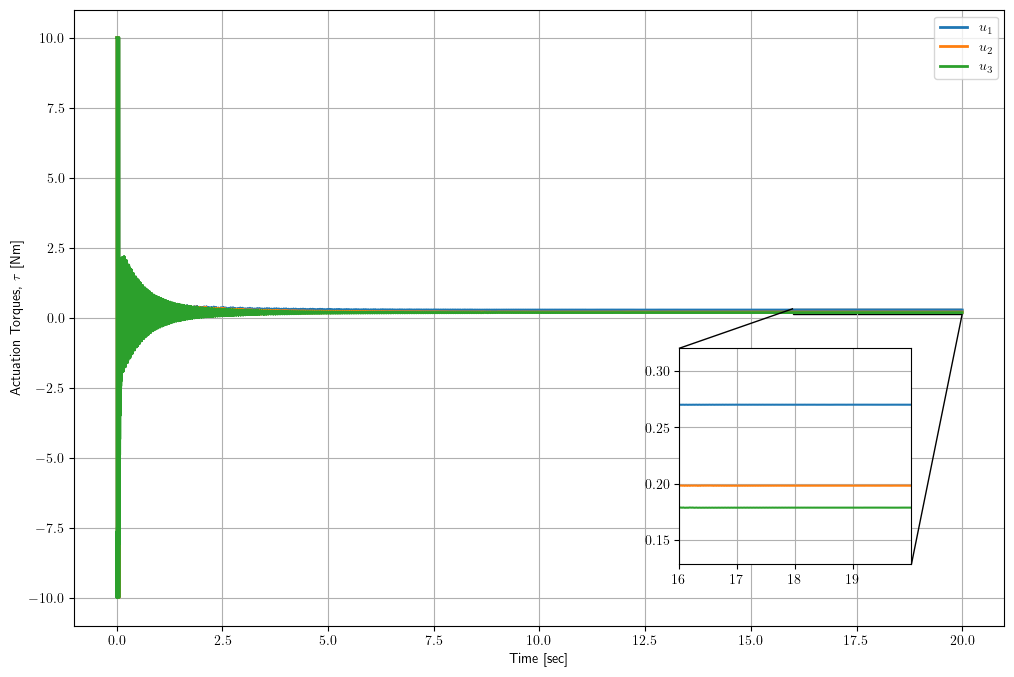

In [7]:
T = 20

dt = 1e-3

NE_simulation = NE_Seeking_Simulation(
    controller=NE_controller,
    T=T,
    dt=dt
)

NE_simulation.simulate()

NE_simulation.plot_results(
    filename=["pcc_NE_q","pcc_NE_u"],
    save=True
)


# 9. Performance Metrics

The framework automatically computes:

- IAE
- ISE
- ITAE
- RMSE

These metrics are implemented in `Metrics.py` and are useful for comparing different control strategies.


# 10. Summary

Workflow:

```text
1. Create PCC_model
2. Build dynamics
3. Choose controller
4. Configure parameters
5. Create simulator
6. Run simulation
7. Analyze KPIs
```

This framework allows direct comparison between optimization-based control (MPC) and game-theoretic control (NE Seeking) using exactly the same PCC robot model.
